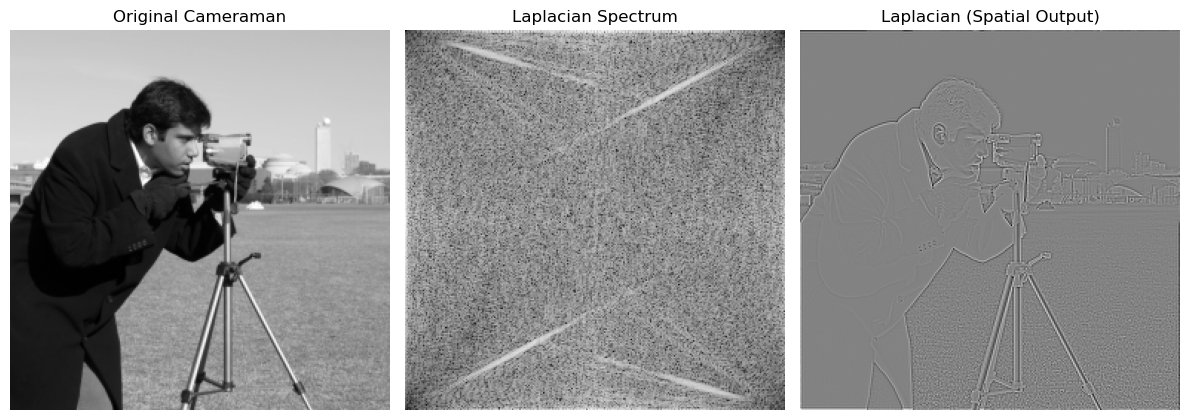

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.transform import resize

# Load cameraman image (already grayscale)
image = data.camera()
image = resize(image, (256, 256)) # Resize for faster FFT (optional)

# Get image size
M, N = image.shape

# Generate frequency grid (centered)
u = np.fft.fftfreq(M).reshape(-1, 1)
v = np.fft.fftfreq(N).reshape(1, -1)

# Compute Laplacian filter in frequency domain
laplacian_filter = -4 * (np.pi ** 2) * (u**2 + v**2)


# Apply 2D FFT
F = np.fft.fft2(image)
# Apply Laplacian filter in frequency domain
F_lap = F * laplacian_filter
# Inverse FFT to get spatial result
laplacian_image = np.fft.ifft2(F_lap).real
# Plot results
plt.figure(figsize=(12, 5))
plt.subplot(1, 3, 1)
plt.imshow(image, cmap='gray')
plt.title('Original Cameraman')
plt.axis('off')
plt.subplot(1, 3, 2)
plt.imshow(np.log(1 + np.abs(F_lap)), cmap='gray')
plt.title('Laplacian Spectrum')
plt.axis('off')
plt.subplot(1, 3, 3)
plt.imshow(laplacian_image, cmap='gray')
plt.title('Laplacian (Spatial Output)')
plt.axis('off')
plt.tight_layout()
plt.show()

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.transform import resize
import cv2

# Load cameraman image (already grayscale)
image = cv2.imread('images/cameraman.png', cv2.IMREAD_GRAYSCALE)
image = resize(image, (256, 256))

# Get image size
M, N = image.shape

# Sobel filters
sobel_x = np.array([[-1, 0, 1],
                    [-2, 0, 2],
                    [-1, 0, 1]])

sobel_y = np.array([[-1, -2, -1],
                    [ 0,  0,  0],
                    [ 1,  2,  1]])

# Proper padding and centering of kernel in spatial domain
def center_embed_kernel(kernel, shape):
    padded = np.zeros(shape)
    kh, kw = kernel.shape
    ph, pw = shape

    # Find center coordinates
    cy, cx = ph // 2, pw // 2

    # Insert kernel centered at the image center
    padded[cy - kh//2:cy - kh//2 + kh,
           cx - kw//2:cx - kw//2 + kw] = kernel

    return np.fft.fft2(np.fft.ifftshift(padded))

# Compute FFT of image
F = np.fft.fft2(image)

# FFT of centered Sobel filters
H_x = center_embed_kernel(sobel_x, image.shape)
H_y = center_embed_kernel(sobel_y, image.shape)

# Multiply in the frequency domain
F_sobel_x = F * H_x
F_sobel_y = F * H_y

# Inverse FFT to get spatial result
sobel_x_image = np.fft.ifft2(F_sobel_x).real
sobel_y_image = np.fft.ifft2(F_sobel_y).real

# Plot
plt.figure(figsize=(10, 5))

plt.subplot(1, 3, 1)
plt.imshow(image, cmap='gray')
plt.title('Original Cameraman')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(sobel_x_image, cmap='gray')
plt.title('Sobel X Output')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(sobel_y_image, cmap='gray')
plt.title('Sobel Y Output')
plt.axis('off')

plt.tight_layout()
plt.show()

AttributeError: 'NoneType' object has no attribute 'shape'

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.transform import resize
import cv2

# Load cameraman image (already grayscale)
image = cv2.imread('images/cameraman.png', cv2.IMREAD_GRAYSCALE)

if image is None:
    raise ValueError("Image not found. Check the file path.")

image = resize(image, (256, 256))
image = resize(image, (256, 256))

# Get image size
M, N = image.shape

# Sobel filters
sobel_x = np.array([[-1, 0, 1],
                    [-2, 0, 2],
                    [-1, 0, 1]])

sobel_y = np.array([[-1, -2, -1],
                    [ 0,  0,  0],
                    [ 1,  2,  1]])

# Proper padding and centering of kernel in spatial domain
def center_embed_kernel(kernel, shape):
    padded = np.zeros(shape)
    kh, kw = kernel.shape
    ph, pw = shape

    # Find center coordinates
    cy, cx = ph // 2, pw // 2

    # Insert kernel centered at the image center
    padded[cy - kh//2:cy - kh//2 + kh,
           cx - kw//2:cx - kw//2 + kw] = kernel

    return np.fft.fft2(np.fft.ifftshift(padded))

# Compute FFT of image
F = np.fft.fft2(image)

# FFT of centered Sobel filters
H_x = center_embed_kernel(sobel_x, image.shape)
H_y = center_embed_kernel(sobel_y, image.shape)

# Multiply in the frequency domain
F_sobel_x = F * H_x
F_sobel_y = F * H_y

# Inverse FFT to get spatial result
sobel_x_image = np.fft.ifft2(F_sobel_x).real
sobel_y_image = np.fft.ifft2(F_sobel_y).real

# Plot
plt.figure(figsize=(10, 5))

plt.subplot(1, 3, 1)
plt.imshow(image, cmap='gray')
plt.title('Original Cameraman')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(sobel_x_image, cmap='gray')
plt.title('Sobel X Output')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(sobel_y_image, cmap='gray')
plt.title('Sobel Y Output')
plt.axis('off')

plt.tight_layout()
plt.show()

ValueError: Image not found. Check the file path.